# Experimentos de modelagem

Notebook independente da API para experimentar os modelos candidatos com `dados_tratados/dados_tratados/dados_para_teste.csv`.

Aqui ficam as listas de features, preprocessamento, metricas, busca de hiperparametros e treino final. Assim voce pode testar mudancas livremente antes de levar algo para a pipeline da API.

## 1. Imports e configuracoes

In [1]:
%pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [2]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 22.1 MB/s eta 0:00:00


In [3]:
from pathlib import Path
from typing import Any, Callable

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
import optuna
try:
    import optuna
except ImportError:
    optuna = None

RAIZ_PROJETO = Path.cwd()
if RAIZ_PROJETO.name == "modelos de aprendizagem":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

DADOS_PATH = Path("/content/dados_para_teste.csv")

# Criando a pasta para salvar os modelos/artefatos dentro do Colab
ARTIFACTS_DIR = Path("/content/artifacts_modelagem")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 3
N_TRIALS = 10
TEST_SIZE = 0.15

## 2. Features e alvo

In [4]:
TARGET = "preco"

NUMERIC_FEATURES = [
    "area_m2",
    "quartos",
    "banheiros",
    "suites",
    "andar",
    "vagas",
]

BOOLEAN_FEATURES = [
    "portaria",
    "vista_mar",
    "condominio_fechado",
    "piscina",
    "deck",
    "varanda_gourmet",
    "varanda",
    "academia",
    "salao_festa",
    "salao_jogos",
    "quadra_campo",
]

CATEGORICAL_FEATURES = [
    "bairro",
    "tipo_imovel_padronizado",
]

MODEL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES + BOOLEAN_FEATURES

## 3. Carregamento dos dados

In [5]:
df = pd.read_csv(DADOS_PATH)

faltantes = [coluna for coluna in MODEL_FEATURES + [TARGET] if coluna not in df.columns]
if faltantes:
    raise ValueError(f"Colunas obrigatorias ausentes: {faltantes}")

dados = df[MODEL_FEATURES + [TARGET]].copy()

for coluna in NUMERIC_FEATURES + [TARGET]:
    dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")

for coluna in BOOLEAN_FEATURES:
    dados[coluna] = dados[coluna].fillna(False).astype(bool)

dados = dados.dropna(subset=MODEL_FEATURES + [TARGET]).reset_index(drop=True)
X = dados[MODEL_FEATURES].copy()
y = dados[TARGET].copy()

print(f"Dataset: {DADOS_PATH}")
print(f"Linhas validas: {len(X)}")
print(f"Colunas: {len(X.columns)} features + alvo")
display(X.head())

Dataset: /content/dados_para_teste.csv
Linhas validas: 824
Colunas: 19 features + alvo


,bairro,tipo_imovel_padronizado,area_m2,quartos,banheiros,suites,andar,vagas,portaria,vista_mar,condominio_fechado,piscina,deck,varanda_gourmet,varanda,academia,salao_festa,salao_jogos,quadra_campo
0,Cambeba,apartamento_padrao,54.0,2.0,2.0,1.0,1.0,1.0,True,False,True,True,True,False,False,True,True,False,True
1,Mondubim,casa_padrao,100.0,3.0,3.0,2.0,0.0,2.0,False,False,False,False,True,False,True,False,False,False,False
2,Aracapé,apartamento_padrao,51.0,2.0,2.0,1.0,1.0,1.0,True,False,True,True,False,True,True,False,True,False,True
3,Aldeota,apartamento_padrao,135.0,3.0,4.0,3.0,0.0,3.0,False,False,False,True,False,False,False,True,True,True,True
4,Mondubim,apartamento_padrao,63.0,3.0,2.0,1.0,2.0,2.0,False,False,False,True,False,False,True,False,False,False,False


## 4. Preprocessamento e metricas

In [6]:
def one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def criar_preprocessador() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot_encoder()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("boolean", "passthrough", BOOLEAN_FEATURES),
        ],
        remainder="drop",
    )


def rmse(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def calcular_metricas(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def criar_pipeline(estimator: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocessor", criar_preprocessador()),
            ("regressor", estimator),
        ]
    )

## 5. Modelos candidatos

In [7]:
def require_xgboost():
    try:
        from xgboost import XGBRegressor
    except ImportError as exc:
        raise ImportError("Instale xgboost para rodar este experimento.") from exc
    return XGBRegressor


def require_lightgbm():
    try:
        from lightgbm import LGBMRegressor
    except ImportError as exc:
        raise ImportError("Instale lightgbm para rodar este experimento.") from exc
    return LGBMRegressor


def require_catboost():
    try:
        from catboost import CatBoostRegressor
    except ImportError as exc:
        raise ImportError("Instale catboost para rodar este experimento.") from exc
    return CatBoostRegressor


def build_xgboost(params: dict[str, Any]):
    XGBRegressor = require_xgboost()
    return XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **params,
    )


def build_lightgbm(params: dict[str, Any]):
    LGBMRegressor = require_lightgbm()
    return LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params,
    )


def build_catboost(params: dict[str, Any]):
    CatBoostRegressor = require_catboost()
    return CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        **params,
    )


def build_random_forest(params: dict[str, Any]):
    return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)


def build_ridge(params: dict[str, Any]):
    return Ridge(random_state=RANDOM_STATE, **params)


def build_lasso(params: dict[str, Any]):
    return Lasso(random_state=RANDOM_STATE, max_iter=10_000, **params)


def build_svr(params: dict[str, Any]):
    return SVR(**params)


def build_mlp(params: dict[str, Any]):
    params = dict(params)
    if "hidden_layer_sizes" not in params:
        width = params.pop("width", 128)
        depth = params.pop("depth", 1)
        params["hidden_layer_sizes"] = tuple([width] * depth)
    else:
        params.pop("width", None)
        params.pop("depth", None)

    return MLPRegressor(
        random_state=RANDOM_STATE,
        early_stopping=True,
        max_iter=700,
        **params,
    )

## 6. Espacos de busca

In [8]:
def suggest_xgboost(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }


def suggest_lightgbm(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 14),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }


def suggest_catboost(trial):
    return {
        "iterations": trial.suggest_int("iterations", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
    }


def suggest_random_forest(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 900, step=100),
        "max_depth": trial.suggest_int("max_depth", 4, 32),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
    }


def suggest_svr(trial):
    return {
        "kernel": trial.suggest_categorical("kernel", ["rbf", "poly"]),
        "C": trial.suggest_float("C", 1.0, 500.0, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.001, 1.0, log=True),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    }


def suggest_mlp(trial):
    width = trial.suggest_categorical("width", [64, 128, 256])
    depth = trial.suggest_int("depth", 1, 3)
    return {
        "hidden_layer_sizes": tuple([width] * depth),
        "activation": trial.suggest_categorical("activation", ["relu", "tanh"]),
        "alpha": trial.suggest_float("alpha", 1e-6, 1e-2, log=True),
        "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
    }


MODEL_SPECS = {
    "xgboost": {"nome": "XGBoost", "builder": build_xgboost, "strategy": "optuna", "suggest": suggest_xgboost},
    "lightgbm": {"nome": "LightGBM", "builder": build_lightgbm, "strategy": "optuna", "suggest": suggest_lightgbm},
    "catboost": {"nome": "CatBoost", "builder": build_catboost, "strategy": "optuna", "suggest": suggest_catboost},
    "random_forest": {"nome": "Random Forest", "builder": build_random_forest, "strategy": "optuna", "suggest": suggest_random_forest},
    "ridge": {"nome": "Ridge", "builder": build_ridge, "strategy": "grid", "grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}},
    "lasso": {"nome": "Lasso", "builder": build_lasso, "strategy": "grid", "grid": {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}},
    "svr": {"nome": "SVR", "builder": build_svr, "strategy": "optuna", "suggest": suggest_svr},
    "mlp": {"nome": "MLPRegressor", "builder": build_mlp, "strategy": "optuna", "suggest": suggest_mlp},
}

list(MODEL_SPECS)

['xgboost',
 'lightgbm',
 'catboost',
 'random_forest',
 'ridge',
 'lasso',
 'svr',
 'mlp']

## 7. Rotinas de treino

In [9]:
def cross_validate_params(builder: Callable[[dict[str, Any]], Any], params: dict[str, Any]) -> dict[str, float]:
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_metrics = []

    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        pipeline = criar_pipeline(builder(params))
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_valid)
        fold_metrics.append(calcular_metricas(y_valid, pred))

    return {
        "rmse": float(np.mean([m["rmse"] for m in fold_metrics])),
        "mae": float(np.mean([m["mae"] for m in fold_metrics])),
        "r2": float(np.mean([m["r2"] for m in fold_metrics])),
    }


def buscar_com_grid(model_key: str, spec: dict[str, Any]) -> tuple[dict[str, Any], dict[str, float]]:
    pipeline = criar_pipeline(spec["builder"]({}))
    grid = {f"regressor__{key}": value for key, value in spec["grid"].items()}
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    search = GridSearchCV(
        pipeline,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X, y)
    best_params = {key.replace("regressor__", ""): value for key, value in search.best_params_.items()}
    best_metrics = cross_validate_params(spec["builder"], best_params)
    return best_params, best_metrics


def buscar_com_optuna(model_key: str, spec: dict[str, Any]) -> tuple[dict[str, Any], dict[str, float]]:
    if optuna is None:
        raise ImportError("Instale optuna para usar busca bayesiana.")

    def objective(trial):
        params = spec["suggest"](trial)
        metrics = cross_validate_params(spec["builder"], params)
        trial.set_user_attr("mae", metrics["mae"])
        trial.set_user_attr("r2", metrics["r2"])
        return metrics["rmse"]

    study = optuna.create_study(direction="minimize", study_name=f"{model_key}_rmse")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    best_params = dict(study.best_params)
    best_metrics = cross_validate_params(spec["builder"], best_params)
    return best_params, best_metrics


def ajustar_modelo_final(builder: Callable[[dict[str, Any]], Any], params: dict[str, Any]) -> Pipeline:
    pipeline = criar_pipeline(builder(params))
    pipeline.fit(X, y)
    return pipeline


rankings = {}


def treinar_modelo(model_key: str) -> pd.DataFrame:
    if model_key not in MODEL_SPECS:
        raise KeyError(f"Modelo desconhecido: {model_key}")

    spec = MODEL_SPECS[model_key]
    print(f"\n=== Treinando {spec['nome']} ===")

    try:
        if spec["strategy"] == "grid":
            best_params, best_metrics = buscar_com_grid(model_key, spec)
        else:
            best_params, best_metrics = buscar_com_optuna(model_key, spec)
    except ImportError as exc:
        print(f"Pulando {spec['nome']}: {exc}")
        return pd.DataFrame()

    estimator = ajustar_modelo_final(spec["builder"], best_params)
    model_dir = ARTIFACTS_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(estimator, model_dir / f"{model_key}.pkl")

    ranking = pd.DataFrame(
        [
            {
                "model_key": model_key,
                "modelo": spec["nome"],
                "rmse": best_metrics["rmse"],
                "mae": best_metrics["mae"],
                "r2": best_metrics["r2"],
                "best_params": best_params,
            }
        ]
    )
    ranking.to_csv(model_dir / "ranking.csv", index=False)
    rankings[model_key] = ranking

    print(
        f"{spec['nome']}: RMSE={best_metrics['rmse']:.2f} | "
        f"MAE={best_metrics['mae']:.2f} | R2={best_metrics['r2']:.4f}"
    )
    print(f"Modelo salvo em: {model_dir / f'{model_key}.pkl'}")
    display(ranking)
    return ranking


def ranking_geral() -> pd.DataFrame:
    if not rankings:
        return pd.DataFrame()
    return pd.concat(rankings.values(), ignore_index=True).sort_values("rmse", ignore_index=True)

## 8. Ridge

In [10]:
ranking_ridge = treinar_modelo("ridge")


=== Treinando Ridge ===
Ridge: RMSE=522598.97 | MAE=320852.33 | R2=0.5414
Modelo salvo em: /content/artifacts_modelagem/ridge/ridge.pkl


,model_key,modelo,rmse,mae,r2,best_params
0,ridge,Ridge,522598.97262,320852.327578,0.541375,{'alpha': 10.0}


## 9. Lasso

In [11]:
ranking_lasso = treinar_modelo("lasso")


=== Treinando Lasso ===
Lasso: RMSE=544567.89 | MAE=348540.65 | R2=0.5037
Modelo salvo em: /content/artifacts_modelagem/lasso/lasso.pkl


,model_key,modelo,rmse,mae,r2,best_params
0,lasso,Lasso,544567.887442,348540.647732,0.503654,{'alpha': 10.0}


## 10. SVR

In [12]:
ranking_svr = treinar_modelo("svr")

[I 2026-06-24 12:05:07,903] A new study created in memory with name: svr_rmse



=== Treinando SVR ===


[I 2026-06-24 12:05:08,205] Trial 0 finished with value: 803887.6564284348 and parameters: {'kernel': 'poly', 'C': 19.497173122630826, 'epsilon': 0.012110939913153027, 'gamma': 'scale'}. Best is trial 0 with value: 803887.6564284348.
[I 2026-06-24 12:05:08,494] Trial 1 finished with value: 804733.752476876 and parameters: {'kernel': 'poly', 'C': 1.417511656851643, 'epsilon': 0.47696491459203355, 'gamma': 'scale'}. Best is trial 0 with value: 803887.6564284348.
[I 2026-06-24 12:05:09,381] Trial 2 finished with value: 802108.4120032154 and parameters: {'kernel': 'rbf', 'C': 110.88606006537229, 'epsilon': 0.09646042588237541, 'gamma': 'scale'}. Best is trial 2 with value: 802108.4120032154.
[I 2026-06-24 12:05:10,155] Trial 3 finished with value: 801313.1350485589 and parameters: {'kernel': 'rbf', 'C': 317.91630327522415, 'epsilon': 0.7638368770600391, 'gamma': 'auto'}. Best is trial 3 with value: 801313.1350485589.
[I 2026-06-24 12:05:10,752] Trial 4 finished with value: 803959.114653704

SVR: RMSE=797102.94 | MAE=487374.85 | R2=-0.0611
Modelo salvo em: /content/artifacts_modelagem/svr/svr.pkl


,model_key,modelo,rmse,mae,r2,best_params
0,svr,SVR,797102.942876,487374.848166,-0.061118,"{'kernel': 'rbf', 'C': 351.088037085919, 'epsi..."


## 11. MLPRegressor

In [13]:
ranking_mlp = treinar_modelo("mlp")

[I 2026-06-24 12:05:13,428] A new study created in memory with name: mlp_rmse



=== Treinando MLPRegressor ===


[I 2026-06-24 12:05:20,113] Trial 0 finished with value: 589631.8483001889 and parameters: {'width': 64, 'depth': 2, 'activation': 'relu', 'alpha': 0.00853201147847395, 'learning_rate_init': 0.008720647320416684, 'batch_size': 128}. Best is trial 0 with value: 589631.8483001889.
[I 2026-06-24 12:05:20,613] Trial 1 finished with value: 1268191.6537473882 and parameters: {'width': 64, 'depth': 2, 'activation': 'relu', 'alpha': 0.0004075717871700138, 'learning_rate_init': 0.0003432861458929645, 'batch_size': 32}. Best is trial 0 with value: 589631.8483001889.
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged y

MLPRegressor: RMSE=543723.34 | MAE=343426.06 | R2=0.5048
Modelo salvo em: /content/artifacts_modelagem/mlp/mlp.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


,model_key,modelo,rmse,mae,r2,best_params
0,mlp,MLPRegressor,543723.341499,343426.056053,0.504844,"{'width': 128, 'depth': 2, 'activation': 'relu..."


## 12. Random Forest

In [14]:
ranking_random_forest = treinar_modelo("random_forest")

[I 2026-06-24 12:06:58,846] A new study created in memory with name: random_forest_rmse



=== Treinando Random Forest ===


[I 2026-06-24 12:07:01,970] Trial 0 finished with value: 478381.5672999544 and parameters: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 478381.5672999544.
[I 2026-06-24 12:07:06,086] Trial 1 finished with value: 521525.284626884 and parameters: {'n_estimators': 600, 'max_depth': 21, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 478381.5672999544.
[I 2026-06-24 12:07:11,070] Trial 2 finished with value: 542344.6876272204 and parameters: {'n_estimators': 800, 'max_depth': 30, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 478381.5672999544.
[I 2026-06-24 12:07:15,306] Trial 3 finished with value: 476559.368112537 and parameters: {'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 1.0}. Best is trial 3 with value: 476559.368112537.
[I 2026-

Random Forest: RMSE=467522.45 | MAE=279195.53 | R2=0.6306
Modelo salvo em: /content/artifacts_modelagem/random_forest/random_forest.pkl


,model_key,modelo,rmse,mae,r2,best_params
0,random_forest,Random Forest,467522.451436,279195.526379,0.630617,"{'n_estimators': 200, 'max_depth': 31, 'min_sa..."


## 13. XGBoost

In [15]:


ranking_xgboost = treinar_modelo("xgboost")

[I 2026-06-24 12:07:33,686] A new study created in memory with name: xgboost_rmse



=== Treinando XGBoost ===


[I 2026-06-24 12:07:36,311] Trial 0 finished with value: 464935.12205113616 and parameters: {'n_estimators': 978, 'learning_rate': 0.012339112180293037, 'max_depth': 9, 'min_child_weight': 5.0712424808336145, 'subsample': 0.659304082239988, 'colsample_bytree': 0.9160452149112243, 'reg_alpha': 3.2892382997110786e-06, 'reg_lambda': 1.0124318627894199e-06}. Best is trial 0 with value: 464935.12205113616.
[I 2026-06-24 12:07:39,315] Trial 1 finished with value: 483666.33279142267 and parameters: {'n_estimators': 1299, 'learning_rate': 0.07408267081014407, 'max_depth': 10, 'min_child_weight': 4.806563989068547, 'subsample': 0.8682474396571302, 'colsample_bytree': 0.7325795724138995, 'reg_alpha': 4.9062230290747024e-08, 'reg_lambda': 0.12099595499628762}. Best is trial 0 with value: 464935.12205113616.
[I 2026-06-24 12:07:43,423] Trial 2 finished with value: 487403.8968839065 and parameters: {'n_estimators': 1214, 'learning_rate': 0.04021341465623865, 'max_depth': 10, 'min_child_weight': 7.3

XGBoost: RMSE=445486.05 | MAE=261269.91 | R2=0.6645
Modelo salvo em: /content/artifacts_modelagem/xgboost/xgboost.pkl


,model_key,modelo,rmse,mae,r2,best_params
0,xgboost,XGBoost,445486.047198,261269.913505,0.664477,"{'n_estimators': 435, 'learning_rate': 0.01174..."


## 14. LightGBM

In [16]:
ranking_lightgbm = treinar_modelo("lightgbm")

[I 2026-06-24 12:07:51,382] A new study created in memory with name: lightgbm_rmse



=== Treinando LightGBM ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-06-24 12:07:57,580] Trial 0 finished with value: 527380.1942613426 and parameters: {'n_estimators': 1444, 'learning_rate': 0.19383574317086638, 'num_leaves': 150, 'max_depth': 11, 'min_child_samples': 43, 'subsample': 0.8270843388414422, 'colsample_bytree': 0.653878989117955, 'reg_alpha': 1.3175410025516114, 'reg_lambda': 0.022135701243116875}. Best is trial 0 with value: 527380.1942613426.
/usr/local/lib/python3.12/dist-

LightGBM: RMSE=469204.98 | MAE=282952.63 | R2=0.6297
Modelo salvo em: /content/artifacts_modelagem/lightgbm/lightgbm.pkl


,model_key,modelo,rmse,mae,r2,best_params
0,lightgbm,LightGBM,469204.980047,282952.630933,0.629682,"{'n_estimators': 418, 'learning_rate': 0.01774..."


## 15. CatBoost

In [17]:
ranking_catboost = treinar_modelo("catboost")

[I 2026-06-24 12:08:01,502] A new study created in memory with name: catboost_rmse



=== Treinando CatBoost ===


[I 2026-06-24 12:08:28,432] Trial 0 finished with value: 454759.5703165513 and parameters: {'iterations': 1362, 'learning_rate': 0.13764498446870463, 'depth': 9, 'l2_leaf_reg': 13.340465675456127, 'bagging_temperature': 0.11791246963724555, 'random_strength': 1.8729308074848052}. Best is trial 0 with value: 454759.5703165513.
[I 2026-06-24 12:08:30,418] Trial 1 finished with value: 446735.51890916337 and parameters: {'iterations': 1422, 'learning_rate': 0.028102286556629507, 'depth': 4, 'l2_leaf_reg': 3.751418128146181, 'bagging_temperature': 0.9278807659711763, 'random_strength': 1.436887156407653}. Best is trial 1 with value: 446735.51890916337.
[I 2026-06-24 12:08:55,997] Trial 2 finished with value: 471687.32166030566 and parameters: {'iterations': 731, 'learning_rate': 0.12218728262398411, 'depth': 10, 'l2_leaf_reg': 3.679647349574363, 'bagging_temperature': 0.625034781576453, 'random_strength': 0.32422167441377603}. Best is trial 1 with value: 446735.51890916337.
[I 2026-06-24 12

CatBoost: RMSE=443818.02 | MAE=250711.62 | R2=0.6657
Modelo salvo em: /content/artifacts_modelagem/catboost/catboost.pkl


,model_key,modelo,rmse,mae,r2,best_params
0,catboost,CatBoost,443818.016242,250711.620173,0.665727,"{'iterations': 741, 'learning_rate': 0.0815930..."


## 16. Ranking consolidado

In [18]:
ranking_final = ranking_geral()
display(ranking_final)

if not ranking_final.empty:
    caminho_ranking_final = ARTIFACTS_DIR / "ranking_geral.csv"
    ranking_final.to_csv(caminho_ranking_final, index=False)
    print(f"Ranking consolidado salvo em: {caminho_ranking_final}")

,model_key,modelo,rmse,mae,r2,best_params
0,catboost,CatBoost,443818.016242,250711.620173,0.665727,"{'iterations': 741, 'learning_rate': 0.0815930..."
1,xgboost,XGBoost,445486.047198,261269.913505,0.664477,"{'n_estimators': 435, 'learning_rate': 0.01174..."
2,random_forest,Random Forest,467522.451436,279195.526379,0.630617,"{'n_estimators': 200, 'max_depth': 31, 'min_sa..."
3,lightgbm,LightGBM,469204.980047,282952.630933,0.629682,"{'n_estimators': 418, 'learning_rate': 0.01774..."
4,ridge,Ridge,522598.972620,320852.327578,0.541375,{'alpha': 10.0}
5,mlp,MLPRegressor,543723.341499,343426.056053,0.504844,"{'width': 128, 'depth': 2, 'activation': 'relu..."
6,lasso,Lasso,544567.887442,348540.647732,0.503654,{'alpha': 10.0}
7,svr,SVR,797102.942876,487374.848166,-0.061118,"{'kernel': 'rbf', 'C': 351.088037085919, 'epsi..."


Ranking consolidado salvo em: /content/artifacts_modelagem/ranking_geral.csv


## 17. Rodar todos os modelos

Use esta celula para executar todos os candidatos em sequencia.

In [19]:
for model_key in MODEL_SPECS:
    if model_key in rankings:
        print(f"Pulando {model_key}: ja executado nesta sessao.")
        continue
    treinar_modelo(model_key)

display(ranking_geral())

Pulando xgboost: ja executado nesta sessao.
Pulando lightgbm: ja executado nesta sessao.
Pulando catboost: ja executado nesta sessao.
Pulando random_forest: ja executado nesta sessao.
Pulando ridge: ja executado nesta sessao.
Pulando lasso: ja executado nesta sessao.
Pulando svr: ja executado nesta sessao.
Pulando mlp: ja executado nesta sessao.


,model_key,modelo,rmse,mae,r2,best_params
0,catboost,CatBoost,443818.016242,250711.620173,0.665727,"{'iterations': 741, 'learning_rate': 0.0815930..."
1,xgboost,XGBoost,445486.047198,261269.913505,0.664477,"{'n_estimators': 435, 'learning_rate': 0.01174..."
2,random_forest,Random Forest,467522.451436,279195.526379,0.630617,"{'n_estimators': 200, 'max_depth': 31, 'min_sa..."
3,lightgbm,LightGBM,469204.980047,282952.630933,0.629682,"{'n_estimators': 418, 'learning_rate': 0.01774..."
4,ridge,Ridge,522598.972620,320852.327578,0.541375,{'alpha': 10.0}
5,mlp,MLPRegressor,543723.341499,343426.056053,0.504844,"{'width': 128, 'depth': 2, 'activation': 'relu..."
6,lasso,Lasso,544567.887442,348540.647732,0.503654,{'alpha': 10.0}
7,svr,SVR,797102.942876,487374.848166,-0.061118,"{'kernel': 'rbf', 'C': 351.088037085919, 'epsi..."


## 18. Comparação de Desempenho dos Modelos

Carregar os resultados do pipeline de Machine Learning e visualizar a tabela comparativa ordenada pela métrica de erro (RMSE).

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Carregar o ranking consolidado
caminho_ranking = ARTIFACTS_DIR / "ranking_geral.csv"
df_ranking = pd.read_csv(caminho_ranking)

# Mostrar a tabela ordenada pelo RMSE (do menor para o maior)
print("Tabela de Desempenho dos Modelos:")
display(df_ranking[['modelo', 'rmse', 'mae', 'r2']].sort_values(by="rmse").reset_index(drop=True))

Tabela de Desempenho dos Modelos:


,modelo,rmse,mae,r2
0,CatBoost,443818.016242,250711.620173,0.665727
1,XGBoost,445486.047198,261269.913505,0.664477
2,Random Forest,467522.451436,279195.526379,0.630617
3,LightGBM,469204.980047,282952.630933,0.629682
4,Ridge,522598.972620,320852.327578,0.541375
5,MLPRegressor,543723.341499,343426.056053,0.504844
6,Lasso,544567.887442,348540.647732,0.503654
7,SVR,797102.942876,487374.848166,-0.061118


## 19. Visualização das Métricas (RMSE e R²)

Gráficos comparativos.
- O **RMSE** mede o erro (quanto menor, melhor).
- O **R²** mede o poder de explicação do modelo (quanto mais próximo de 1, melhor).

/tmp/ipykernel_757/725014223.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ranking.sort_values('rmse'), x='rmse', y='modelo', ax=axes[0], palette='viridis')
/tmp/ipykernel_757/725014223.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ranking.sort_values('r2', ascending=False), x='r2', y='modelo', ax=axes[1], palette='magma')


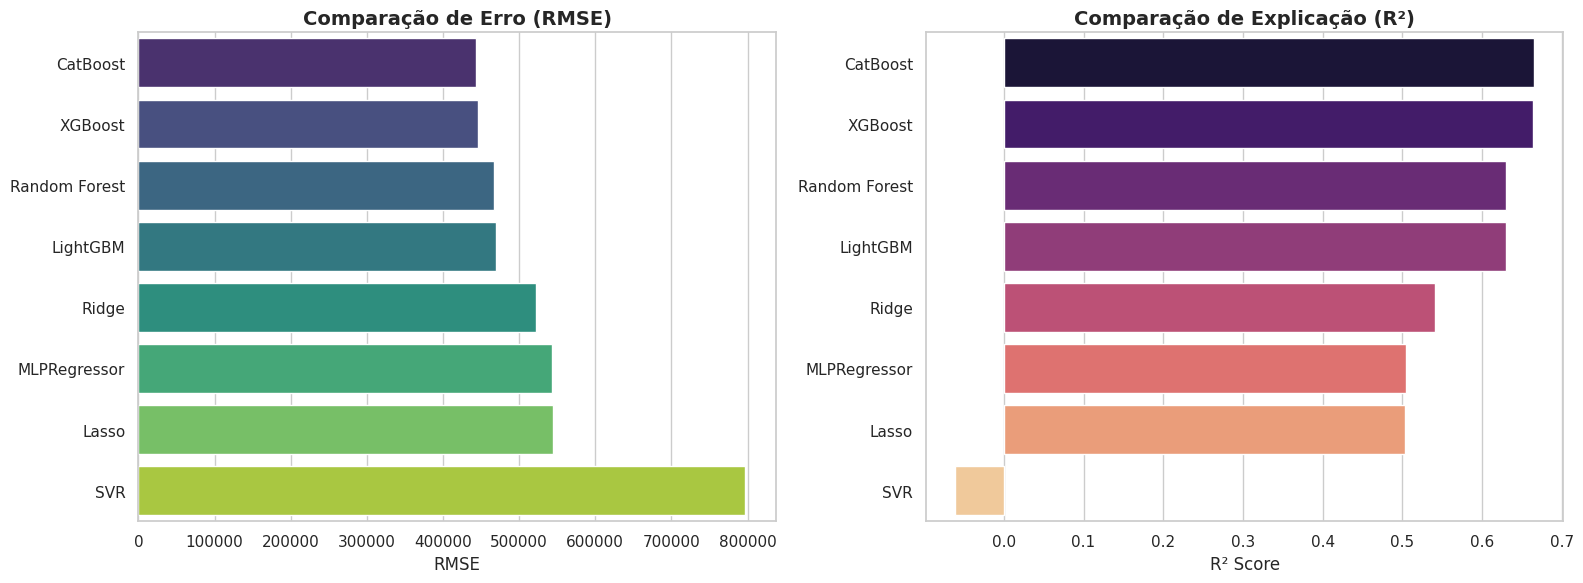

In [26]:
# Configuração de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de RMSE
sns.barplot(data=df_ranking.sort_values('rmse'), x='rmse', y='modelo', ax=axes[0], palette='viridis')
axes[0].set_title('Comparação de Erro (RMSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('')

# Gráfico de R_2
sns.barplot(data=df_ranking.sort_values('r2', ascending=False), x='r2', y='modelo', ax=axes[1], palette='magma')
axes[1].set_title('Comparação de Explicação (R²)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('R² Score')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 20. Avaliação do melhor modelo: Análise de Resíduos

Análise de resíduos no melhor modelo para diagnosticar problemas como underfitting, overfitting ou heterocedasticidade.

Melhor modelo: CATBOOST


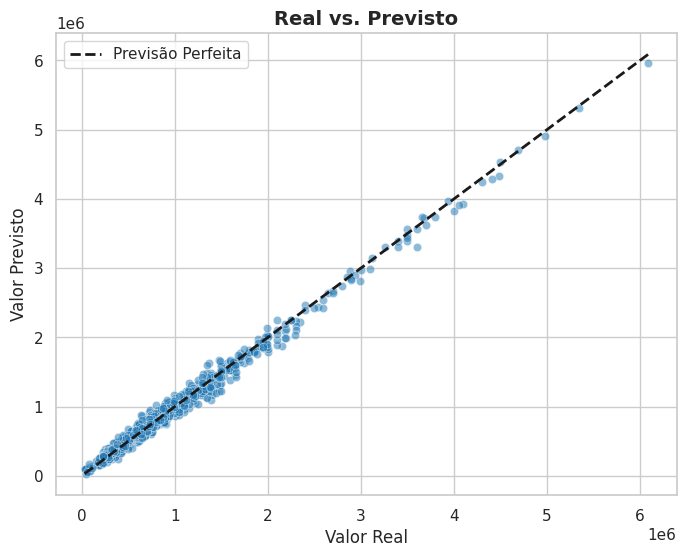

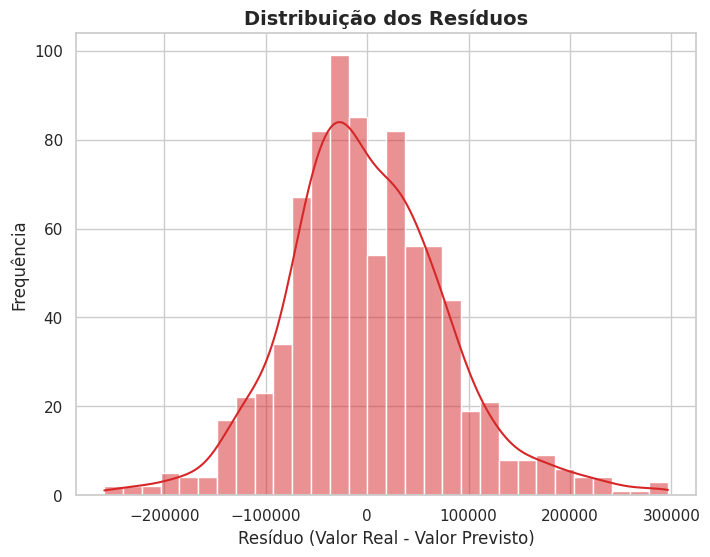

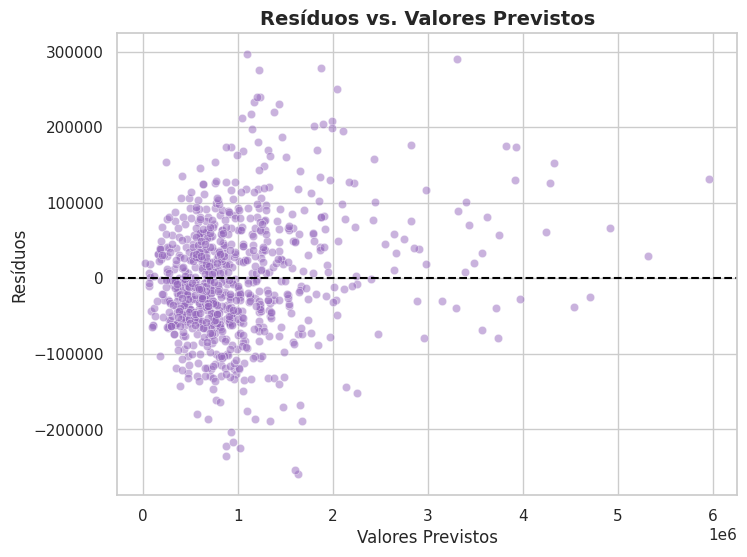

In [28]:
# Identificar o nome do melhor modelo (a primeira linha ordenado por RMSE)
melhor_model_key = df_ranking.sort_values('rmse').iloc[0]['model_key']
print(f"Melhor modelo: {melhor_model_key.upper()}")

caminho_modelo = ARTIFACTS_DIR / melhor_model_key / f"{melhor_model_key}.pkl"
melhor_modelo = joblib.load(caminho_modelo)

# Fazer a predição com os dados de teste/validação
y_pred = melhor_modelo.predict(X)
residuos = y - y_pred

#  Valores Reais vs. Previstos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.5, color="#1f77b4")
# Real == Previsto
min_val, max_val = y.min(), y.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Previsão Perfeita")
plt.title("Real vs. Previsto", fontsize=14, fontweight='bold')
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.legend()
plt.show()

# Histograma dos Resíduos (Erros)
plt.figure(figsize=(8, 6))
sns.histplot(residuos, kde=True, color="#d62728", bins=30)
plt.title("Distribuição dos Resíduos", fontsize=14, fontweight='bold')
plt.xlabel("Resíduo (Valor Real - Valor Previsto)")
plt.ylabel("Frequência")
plt.show()

# Resíduos vs. Valores Ajustados
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, color="#9467bd")
plt.axhline(0, color='black', linestyle='--')
plt.title("Resíduos vs. Valores Previstos", fontsize=14, fontweight='bold')
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos")
plt.show()